<a href="https://colab.research.google.com/github/aboettcher-sig/morocco-forests-sig/blob/main/scripts/analysis/analyze_gee_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Per-point multi-source time series

Reads the SQLite database built by load_gee_data (pulled onto local disk) and,
for any index point, gathers the full time series of every dataset at that
point and assembles them into one dataframe.

The index is the Landsat 8 unique-locations table. Every other dataset sits on
its own grid with its own `unique_loc_id` space, so a location crosswalk maps
each Landsat 8 point to the nearest location in every other table (built once,
it's static geometry). `get_matching_rows` then pulls each table's full series
for a point by that matched id, and `assemble_point_series` harmonizes the
Landsat sensors, merges the climate and land-cover series on date, attaches the
static terrain values, and returns one wide series keyed by the point.

Adapted from the Hawaii soils retrieval. Simplified because this database
already carries a real `date` column and `unique_loc_id`, so no index-string
parsing and no all-pairs distance chunking are needed.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import os

run_name = "cwcb_water_use_2026_08_12_1300"

drive_db_path = f"/content/drive/MyDrive/{run_name}/{run_name}.sqlite"
local_db_path = f"/content/{run_name}.sqlite"

LOCATION_TABLE = "landsat_8"   # canonical point-location index for the analysis
ANALYSIS_START = "2014-01-01"  # pre-2014 Landsat 5/7 data is unusable here
QA_MASK = False                 # apply QA_PIXEL to Landsat 8/9

In [25]:
import shutil

shutil.copy(drive_db_path, local_db_path)
print(f"Copied database to {local_db_path} "
      f"({os.path.getsize(local_db_path) / 1e6:.1f} MB)")

Copied database to /content/cwcb_water_use_2026_08_12_1300.sqlite (131.5 MB)


In [26]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Schema helpers

In [27]:
META_COLS = {"image_id", "date", "lon", "lat", "unique_loc_id"}
LANDSAT_TABLES = ["landsat_8", "landsat_9"]


def data_tables(conn):
    """Data tables that have a `_unique_locs` companion, in a stable order."""
    rows = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name LIKE '%_unique_locs';"
    ).fetchall()
    return sorted(r[0][:-len("_unique_locs")] for r in rows)


def value_columns(conn, table):
    """Value columns of a table (everything that isn't identity/metadata)."""
    cols = [row[1] for row in conn.execute(f"PRAGMA table_info(`{table}`)")]
    return [c for c in cols if c not in META_COLS]


def load_unique_locs(conn, table):
    """The `id, lat, lon` rows of a table's `_unique_locs` companion."""
    return pd.read_sql_query(
        f"SELECT id, lat, lon FROM `{table}_unique_locs` ORDER BY id", conn
    )

# Location crosswalk

For each Landsat 8 point, the nearest location id in every dataset's
`_unique_locs` (great-circle nearest neighbour). One row per index point,
one column per dataset. This is pure geometry, computed once; it does not
change as timestamps accumulate.

In [28]:
def build_crosswalk(conn, location_table, tables):
    """Map every location_table point to the nearest unique-loc id per table."""
    base = load_unique_locs(conn, location_table)
    base_rad = np.radians(base[["lat", "lon"]].values)

    xwalk = pd.DataFrame({"point_id": base["id"].values}).set_index("point_id")
    for t in tables:
        if t == location_table:
            xwalk[t] = base["id"].values           # self-map
            continue
        locs = load_unique_locs(conn, t)
        if locs.empty:
            xwalk[t] = pd.NA
            continue
        tree = BallTree(np.radians(locs[["lat", "lon"]].values), metric="haversine")
        nn = tree.query(base_rad, k=1, return_distance=False).ravel()
        xwalk[t] = locs["id"].values[nn]
    return xwalk

In [29]:
conn = sqlite3.connect(local_db_path)
try:
    DATA_TABLES = data_tables(conn)
    print("data tables:", DATA_TABLES)

    crosswalk = build_crosswalk(conn, LOCATION_TABLE, DATA_TABLES)
    print(f"crosswalk: {len(crosswalk)} index points -> matched ids in {len(DATA_TABLES)} tables")
    print(crosswalk.head())
finally:
    conn.close()

data tables: ['dynamic_world', 'landsat_5', 'landsat_7', 'landsat_8', 'landsat_9', 'terraclimate', 'terrain_aspect', 'terrain_elevation', 'terrain_mTPI', 'terrain_slope']
crosswalk: 150 index points -> matched ids in 10 tables
          dynamic_world  landsat_5  landsat_7  landsat_8  landsat_9  \
point_id                                                              
1                    47         52        105          1        126   
2                   110         76         98          2         56   
3                   634         11        101          3         94   
4                   101        113         91          4        101   
5                   293         31         53          5         36   

          terraclimate  terrain_aspect  terrain_elevation  terrain_mTPI  \
point_id                                                                  
1                    7           11158              19576            29   
2                    7            2343            

# Landsat band harmonization

Common band names across sensors, so all four Landsat records stack into one
spectral series. Corrected for Collection 2 Level 2: thermal is `ST_B6`
(TM/ETM+) and `ST_B10` (OLI/TIRS); the panchromatic, cirrus, and second
thermal bands are not in the surface-reflectance product and are omitted.
`harmonize` skips any source band a table doesn't actually have.

In [30]:
LANDSAT_BAND_ALIGNMENT = {
    "Blue":    {"landsat_5": "SR_B1", "landsat_7": "SR_B1", "landsat_8": "SR_B2", "landsat_9": "SR_B2"},
    "Green":   {"landsat_5": "SR_B2", "landsat_7": "SR_B2", "landsat_8": "SR_B3", "landsat_9": "SR_B3"},
    "Red":     {"landsat_5": "SR_B3", "landsat_7": "SR_B3", "landsat_8": "SR_B4", "landsat_9": "SR_B4"},
    "NIR":     {"landsat_5": "SR_B4", "landsat_7": "SR_B4", "landsat_8": "SR_B5", "landsat_9": "SR_B5"},
    "SWIR-1":  {"landsat_5": "SR_B5", "landsat_7": "SR_B5", "landsat_8": "SR_B6", "landsat_9": "SR_B6"},
    "SWIR-2":  {"landsat_5": "SR_B7", "landsat_7": "SR_B7", "landsat_8": "SR_B7", "landsat_9": "SR_B7"},
    "Thermal": {"landsat_5": "ST_B6", "landsat_7": "ST_B6", "landsat_8": "ST_B10", "landsat_9": "ST_B10"},
}
COMMON_BANDS = list(LANDSAT_BAND_ALIGNMENT)


def is_clear(qa_pixel):
    """Landsat 8/9 QA_PIXEL: reject fill, dilated cloud, cirrus, cloud, shadow, and snow."""
    if pd.isna(qa_pixel):
        return False
    qa = int(qa_pixel)
    return not any((qa >> bit) & 1 for bit in (0, 1, 2, 3, 4, 5))


def harmonize_landsat(rows, qa_mask=True):
    """Stack the Landsat sensors present into one date-sorted spectral series."""
    frames = []
    for t in LANDSAT_TABLES:
        if t not in rows:
            continue
        df = rows[t]
        df = df[df["date"] >= ANALYSIS_START]
        if qa_mask and "QA_PIXEL" in df.columns:
            df = df[df["QA_PIXEL"].apply(is_clear)]
        if df.empty:
            continue
        rec = pd.DataFrame({"date": df["date"].values})
        for band, per_sensor in LANDSAT_BAND_ALIGNMENT.items():
            src = per_sensor.get(t)
            rec[band] = pd.to_numeric(df[src], errors="coerce").values if src in df.columns else np.nan
        frames.append(rec)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).dropna(how="all", subset=COMMON_BANDS)
    return out.sort_values("date").reset_index(drop=True)

# Per-point retrieval and assembly

`get_matching_rows` pulls each table's full series for one index point.
`assemble_point_series` builds the wide multi-source series on the Landsat
observation dates: climate and land-cover merged by nearest prior date, terrain
attached as static columns, day-of-year encoded.

In [31]:
def get_matching_rows(point_id, conn):
    """{table: full series DataFrame} for one index point, via the crosswalk."""
    matched = crosswalk.loc[point_id]
    out = {}
    for t in DATA_TABLES:
        loc_id = matched[t]
        if pd.isna(loc_id):
            continue
        df = pd.read_sql_query(
            f"SELECT * FROM `{t}` WHERE unique_loc_id = ? ORDER BY date",
            conn, params=(int(loc_id),),
        )
        if not df.empty:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            out[t] = df
    return out


def assemble_point_series(point_id, qa_mask=True):
    """One wide multi-source series for an index point, on Landsat dates."""
    conn = sqlite3.connect(local_db_path)
    try:
        rows = get_matching_rows(point_id, conn)

        base = harmonize_landsat(rows, qa_mask=qa_mask)
        if base.empty:
            return pd.DataFrame()
        base = base.dropna(subset=["date"]).sort_values("date")

        # Climate and land cover: use only the most recent prior observation.
        # This prevents Dynamic World (which begins in 2015) leaking backward.
        for table in ["terraclimate", "dynamic_world"]:
            if table in rows:
                ser = rows[table].dropna(subset=["date"]).sort_values("date")
                cols = [c for c in value_columns(conn, table) if c in ser.columns]
                base = pd.merge_asof(base, ser[["date"] + cols], on="date", direction="backward")

        # terrain: static per point
        for table in [t for t in rows if t.startswith("terrain_")]:
            col = value_columns(conn, table)[0]
            val = float(rows[table].iloc[0][col])
            if table == "terrain_aspect":                 # aspect is circular; encode in radians
                rad = np.radians(val)
                base["aspect_sin"], base["aspect_cos"] = np.sin(rad), np.cos(rad)
            else:
                base[col if col not in base.columns else table] = val
    finally:
        conn.close()

    # day-of-year encoding
    doy = base["date"].dt.dayofyear
    base["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    base["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    base["point_id"] = point_id
    return base.reset_index(drop=True)

# Example: full series for one index point

In [32]:
# Pick the first index point that yields an assembled series
example = pd.DataFrame()
for pid in crosswalk.index:
    example = assemble_point_series(int(pid), qa_mask=QA_MASK)
    if not example.empty:
        example_id = int(pid)
        break

print(f"point {example_id}: {len(example)} observations, {example.shape[1]} columns")
print("columns:", list(example.columns))
print(example.head())

point 1: 1058 observations, 40 columns
columns: ['date', 'Blue', 'Green', 'Red', 'NIR', 'SWIR-1', 'SWIR-2', 'Thermal', 'aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs', 'bare', 'built', 'crops', 'flooded_vegetation', 'grass', 'label', 'shrub_and_scrub', 'snow_and_ice', 'trees', 'water', 'aspect_sin', 'aspect_cos', 'elevation', 'terrain_mTPI', 'slope', 'doy_sin', 'doy_cos', 'point_id']
        date   Blue  Green    Red    NIR  SWIR-1  SWIR-2  Thermal  aet  def  \
0 2014-01-07  52406  49744  48940  46300   23767   25279    16551   10    0   
1 2014-01-16  11934  13986  14618  17277   15264   14421    32108   10    0   
2 2014-01-16  11721  13868  14473  17273   15234   14345    32108   10    0   
3 2014-01-23  29669  29336  29939  30535   10483   10871    33728   10    0   
4 2014-02-01  42872  40035  40302  38561   28766   26509    32801    4    0   

   ...  trees  water  aspect_sin  aspect_cos  elevation  terrain_mTPI  \
0  ...    NaN 

# Assemble a sample of points

The same call over many points concatenates into the long panel the downstream
analysis (feature extraction, decomposition, or a model feed) reads from.

In [33]:
SAMPLE_N = 3  # cap for a quick pass; raise to len(crosswalk) for all points

panel = []
for pid in crosswalk.index[:SAMPLE_N]:
    s = assemble_point_series(int(pid), qa_mask=QA_MASK)
    if not s.empty:
        panel.append(s)

panel = pd.concat(panel, ignore_index=True) if panel else pd.DataFrame()
print(f"assembled {panel['point_id'].nunique() if len(panel) else 0} points, {len(panel)} rows total")

assembled 1 points, 1058 rows total


# Temporal features and decomposition

The analysis from the reference notebook, now run on a column of the assembled
multi-source panel. Per point: mean, std, cv, a linear trend, and an FFT
seasonal amplitude/phase; then the per-point series are averaged and decomposed
additively into trend, seasonal, and residual. Set VALUE_COL to any assembled
column (a harmonized Landsat band, a climate variable, a derived index).

In [34]:
VALUE_COL = "Green"          # assembled column to analyze
RESAMPLE_RULE = "MS"       # regular step for irregular series (MS = month start)
SEASONAL_PERIOD = 12       # steps per cycle after resampling (12 monthly = annual)


def regularize(series, rule):
    """Put an irregular series on a regular step (mean per bin) and fill gaps."""
    s = series.resample(rule).mean()
    return s.interpolate(method="linear", limit_area="inside")


def extract_temporal_features(values, period):
    """Mean, std, cv, linear trend, and FFT seasonal amplitude/phase."""
    features = {}
    features["mean"] = np.mean(values)
    features["std"] = np.std(values)
    features["cv"] = features["std"] / features["mean"] if features["mean"] != 0 else 0

    x = np.arange(len(values))
    slope, intercept, r_value, _, _ = stats.linregress(x, values)
    features["trend_slope"] = slope
    features["trend_r2"] = r_value ** 2

    detrended = values - (slope * x + intercept)
    if len(values) >= period * 2:
        fft = np.fft.fft(detrended)
        freqs = np.fft.fftfreq(len(detrended))
        seasonal_idx = np.argmin(np.abs(freqs - 1.0 / period))
        features["seasonal_amplitude"] = np.abs(fft[seasonal_idx]) / len(values)
        features["seasonal_phase"] = np.angle(fft[seasonal_idx])
    else:
        features["seasonal_amplitude"] = 0
        features["seasonal_phase"] = 0
    return features

In [35]:
# Per-point regularized series and temporal features for VALUE_COL
series_by_point = {}
records = []
for pid, group in panel.groupby("point_id"):
    s = regularize(group.set_index("date")[VALUE_COL].astype(float).sort_index(), RESAMPLE_RULE)
    if s.dropna().empty:
        continue
    series_by_point[pid] = s
    feats = extract_temporal_features(s.values, SEASONAL_PERIOD)
    feats["point_id"] = pid
    records.append(feats)

features_df = pd.DataFrame(records)
print(f"Temporal features for {len(features_df)} points on {VALUE_COL}")
print(features_df.describe())

Temporal features for 1 points on Green
               mean          std        cv  trend_slope  trend_r2  \
count      1.000000     1.000000  1.000000     1.000000  1.000000   
mean   16151.149853  4828.622158  0.298965   -16.240531  0.019547   
std             NaN          NaN       NaN          NaN       NaN   
min    16151.149853  4828.622158  0.298965   -16.240531  0.019547   
25%    16151.149853  4828.622158  0.298965   -16.240531  0.019547   
50%    16151.149853  4828.622158  0.298965   -16.240531  0.019547   
75%    16151.149853  4828.622158  0.298965   -16.240531  0.019547   
max    16151.149853  4828.622158  0.298965   -16.240531  0.019547   

       seasonal_amplitude  seasonal_phase  point_id  
count            1.000000        1.000000       1.0  
mean          1343.502201       -0.507892       1.0  
std                   NaN             NaN       NaN  
min           1343.502201       -0.507892       1.0  
25%           1343.502201       -0.507892       1.0  
50%           

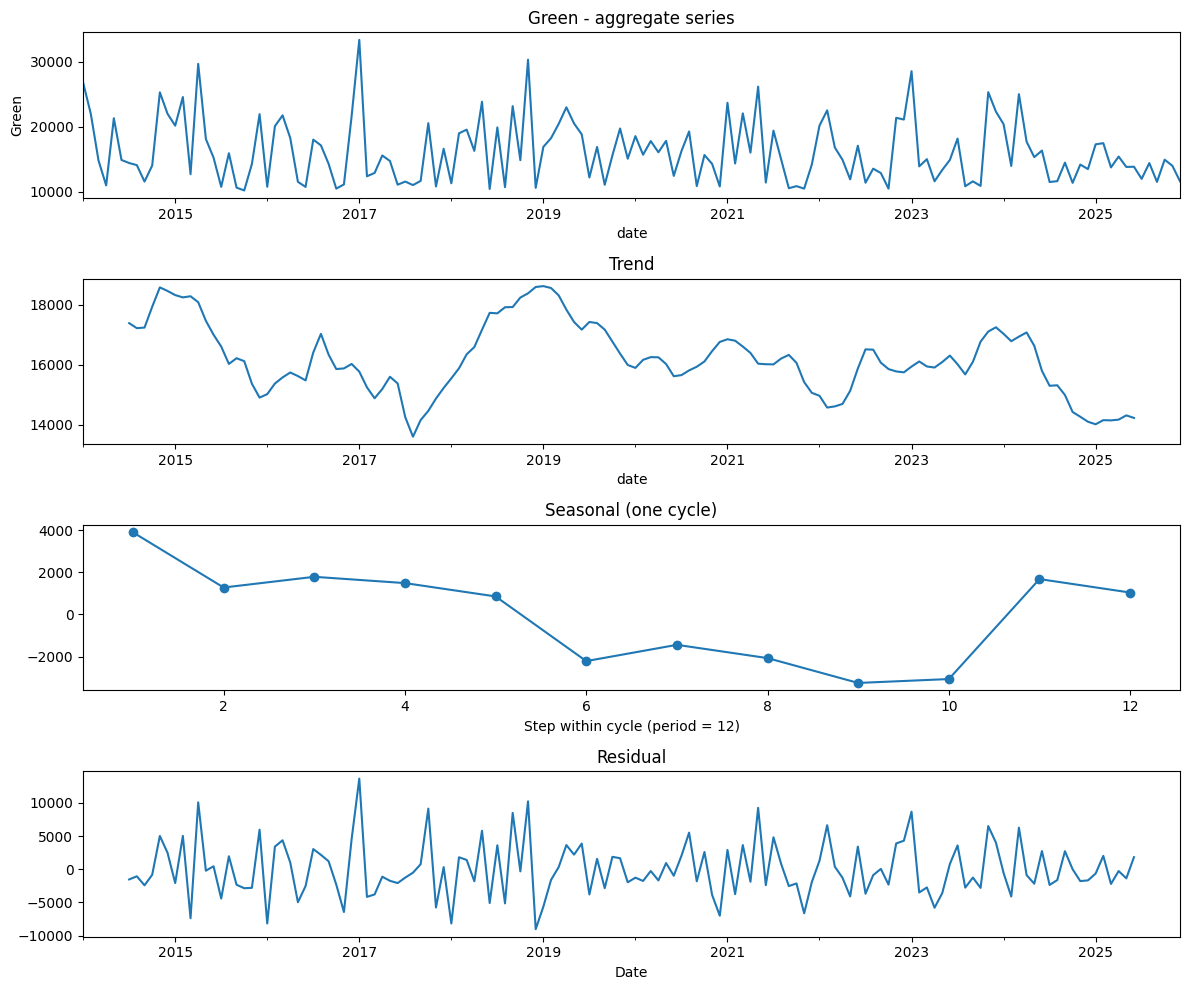

In [36]:
# Aggregate series across points, decomposed into trend / seasonal / residual
ts_panel = pd.DataFrame(series_by_point)
mean_series = ts_panel.mean(axis=1).dropna()

decomposition = seasonal_decompose(mean_series, model="additive", period=SEASONAL_PERIOD)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
mean_series.plot(ax=axes[0], title=f"{VALUE_COL} - aggregate series")
axes[0].set_ylabel(VALUE_COL)
decomposition.trend.plot(ax=axes[1], title="Trend")
# one cycle of the seasonal component (it repeats identically every year)
one_cycle = decomposition.seasonal.iloc[:SEASONAL_PERIOD]
axes[2].plot(range(1, SEASONAL_PERIOD + 1), one_cycle.values, marker="o")
axes[2].set_title("Seasonal (one cycle)")
axes[2].set_xlabel(f"Step within cycle (period = {SEASONAL_PERIOD})")
decomposition.resid.plot(ax=axes[3], title="Residual")
axes[3].set_xlabel("Date")
plt.tight_layout()
plt.show()

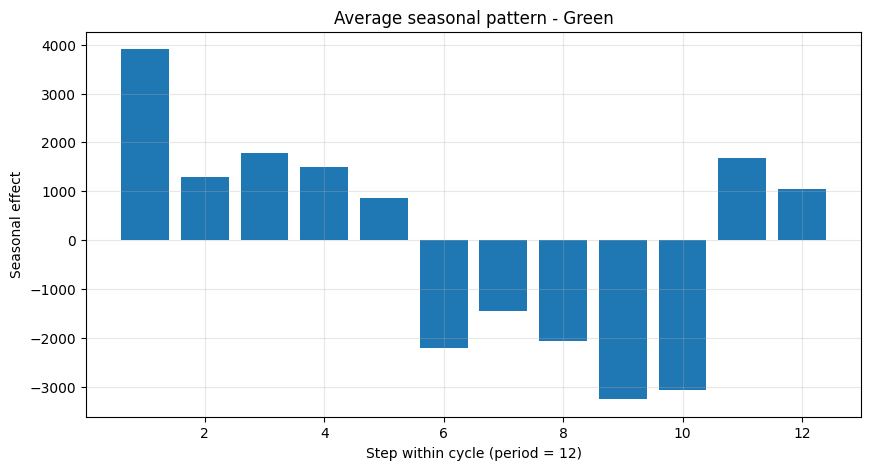

In [37]:
# Average seasonal pattern over one cycle
seasonal_cycle = decomposition.seasonal.iloc[:SEASONAL_PERIOD]
plt.figure(figsize=(10, 5))
plt.bar(range(1, SEASONAL_PERIOD + 1), seasonal_cycle.values)
plt.title(f"Average seasonal pattern - {VALUE_COL}")
plt.xlabel(f"Step within cycle (period = {SEASONAL_PERIOD})")
plt.ylabel("Seasonal effect")
plt.grid(True, alpha=0.3)
plt.show()

# Summary

In [38]:
print("=" * 60)
print("TEMPORAL ANALYSIS SUMMARY")
print("=" * 60)
print(f"Location index      : {LOCATION_TABLE}_unique_locs")
print(f"Analyzed column     : {VALUE_COL} (from the assembled multi-source panel)")
print(f"Points analyzed     : {len(features_df)}")
print(f"Series span         : {mean_series.index.min().date()} to {mean_series.index.max().date()}")
print(f"Steps per series    : {len(mean_series)} (period {SEASONAL_PERIOD})")
print(f"Mean trend slope    : {features_df['trend_slope'].mean():.6g} per step")
print(f"Mean seasonal amp.  : {features_df['seasonal_amplitude'].mean():.6g}")

TEMPORAL ANALYSIS SUMMARY
Location index      : landsat_8_unique_locs
Analyzed column     : Green (from the assembled multi-source panel)
Points analyzed     : 1
Series span         : 2014-01-01 to 2025-12-01
Steps per series    : 144 (period 12)
Mean trend slope    : -16.2405 per step
Mean seasonal amp.  : 1343.5
